In [1]:
#!pip install camb

In [2]:
# Main dependencies
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# This is where we import functions for generating Gaussian random fields and galaxy fields
# generated from those Gaussian random fields from Gaussian_Galaxy_Field_Generation.py
import Gaussian_Galaxy_Field_Generation as ggfg

# Import functions for creating and training CNN from Create_Train_Net.py
import Create_Train_Net as ctn

# prints number of GPUs available
print(torch.cuda.device_count())

4


In [3]:
import importlib
importlib.reload(ctn)
importlib.reload(ggfg);

In [4]:
h = 0.7             # Dimensionless Hubble constant
field_size = 32     # Size of the cube output Gaussian/galaxy fields
max_stretch = 1.1   # Maximum factor by which fields at stretched in AP-like fashion
fields_num = 100    # Number of fields to create for training
test_frac = 0.2     # Fraction of fields generated to use for validation
batch = 20          # Batch size when training
epoch_num = 1000    # Number of epochs to train for
arch_choice = 'OG'  # Choose CNN architecture
opt_choice = 'SGD'  # Choose optimizer for training CNN

# Many functions in these modules need common access to variables defined by the user in 
# this notebook. We initialize those modules such that those variables are globalized
ggfg.initialize(h, field_size, max_stretch)
ctn.initialize(field_size, fields_num, test_frac, batch)

ggfg initialized!
ctn initialized!


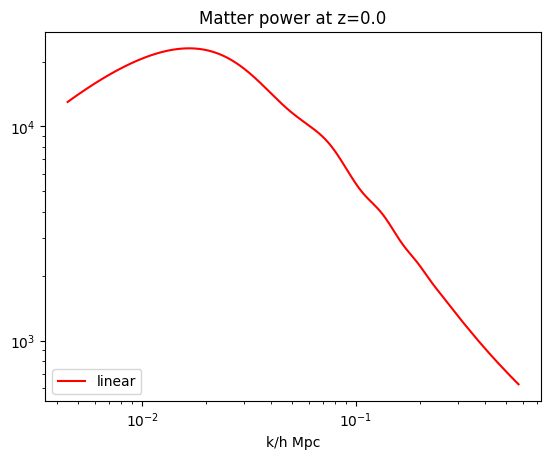

In [5]:
# Quick detour to plot power spectrum

pk, kh = ggfg.camb_matter_power_spectrum()  # Get matter power spectrum evaluated over a range of k-values

plt.loglog(kh, pk, color='r')
plt.xlabel('k/h Mpc')
plt.legend(['linear', 'non-linear'], loc='lower left')
plt.title('Matter power at z=%s' % 0.0);

When I multiply the k's along some axis by a stretch factor, let's say 2, I am considering up to 2 times larger k's and twice as large of a minimum k. This means that the total length of space considered along that axis is a factor of 2 smaller, but I have twice the resolution. Similarly, by dividing the total length of space considered along an axis by a stretch factor, let's say 2 again, I am considering k's that are not quite as large but a smaller minimum k. This translates to a greater length of space considered along that axis just at smaller resolution.

In [6]:
# This is to figure out how many galaxies I would have in a box for each tracer
k_min = 1/1000 # Mpc^-1
box_volume = k_min ** -3 # Mpc^3
vol_tracer = 10**9 #Mpc^3
N_gal_tracer = 10**6

N_gal = round(N_gal_tracer / vol_tracer * box_volume) # multiply measured galaxy density by volume of my box
print(N_gal)

1000000


In [7]:
# Here we make the training data with each individual image stretched by a different random amount

# Numpy array to store labels
labels = torch.zeros(fields_num)

# Numpy array to store field data
Gal_fields = torch.zeros([fields_num, 1, field_size, field_size, field_size])

for num in range(fields_num):
    #return 3D array with values representing a galaxy field
    Gal_field, stretch = ggfg.Gaussian_to_Galaxy_Field(N_gal)

    #normalize all values in 3D array to be between 0 and 1
    Gal_field_normal = Gal_field / np.mean(Gal_field) 
        
    # Convert into a tensor
    Gal_field_tensor = torch.tensor(Gal_field_normal, dtype=torch.float)
    Gal_fields[num][0] = Gal_field_tensor
    labels[num] = stretch

In [8]:
'''
# Verify that galaxy fields are being generated correctly
for i in range(10):
    plt.imshow(Gal_fields[i][0][0], cmap = 'gray')
    plt.show()
    print(labels[i])

print(Gal_fields[10][0][0])
print(torch.max(Gal_fields[10][0][0]))
''';

In [9]:
from sklearn.model_selection import train_test_split
train_num = fields_num * (1 - test_frac)
test_num = fields_num * test_frac
# Right now, I am just using the Gaussian fields for training
fields_train, fields_test, labels_train, labels_test = train_test_split(Gal_fields, labels, test_size = test_frac, random_state = 42)

#This class is meant to take arrays of pixel values and labels and prepare them in a state that the dataloader 
#can process and then give to the neural network
class CustomThrimageDataset():
    def __init__(self, labels, data, transforms = False):
        self.labels = labels
        self.data = data
        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        thrimage = self.data[idx]
        label = self.labels[idx]
        clonethrimage = thrimage.clone()
        if self.transforms:
            clonethrimage = self.transforms(clonethrimage)
        return clonethrimage, label

In [10]:
#Here we actually define the training and testing datasets in a way that the dataloader can process
training_thrimages = CustomThrimageDataset(labels_train, fields_train)
testing_thrimages = CustomThrimageDataset(labels_test, fields_test)

#Here we tell the dataloader what datasets we are giving it, how many images we want for each batch of training and whether we want the datasets
#to be shuffled between "rounds" of training
train_dataloader = DataLoader(training_thrimages, batch_size=batch, shuffle=True)
test_dataloader = DataLoader(testing_thrimages, batch_size=batch, shuffle=True)

In [11]:
# Define architecture based on pre-existing options in 'Create_Train_Net.py'
net = ctn.choose_model_architecture(arch_choice, field_size)

device = torch.device("cuda:0")
net.to(device);

In [12]:
criterion = nn.MSELoss()
lr = 0.001
# Define optimizer based on pre-existing options in 'Create_Train_Net.py'
optimizer = ctn.choose_optimizer(opt_choice, net, lr)

In [13]:
# Train network
ctn.train_network(train_dataloader, test_dataloader, epoch_num, device, net, optimizer, criterion)

[1] loss: 0.964587
Average deviation of network guess from actual stretch is approximately: 0.775
[2] loss: 0.524869
Average deviation of network guess from actual stretch is approximately: 0.560
[3] loss: 0.402585
Average deviation of network guess from actual stretch is approximately: 0.387
[4] loss: 0.396608
Average deviation of network guess from actual stretch is approximately: 0.209
[5] loss: 0.235262
Average deviation of network guess from actual stretch is approximately: 0.227
[6] loss: 0.174848
Average deviation of network guess from actual stretch is approximately: 0.253
[7] loss: 0.198835
Average deviation of network guess from actual stretch is approximately: 0.063
[8] loss: 0.152550
Average deviation of network guess from actual stretch is approximately: 0.084
[9] loss: 0.097739
Average deviation of network guess from actual stretch is approximately: 0.153
[10] loss: 0.107752
Average deviation of network guess from actual stretch is approximately: 0.070
[11] loss: 0.096903

KeyboardInterrupt: 

In [ ]:
plt.semilogy(epochs, train_loss, label = "Training")
plt.semilogy(epochs, val_loss, label = "Validation")
plt.title(f"Galaxy, Num Fields = {fields_num}, Model Number is {model_num}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim(0.034, 0.065)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(f"Galaxy_{fields_num}_{model_num}_{epoch_num}_smaller_stretch.pdf")

In [ ]:
print(np.sqrt(best_loss))